# Flux vacua ensembles via ISD sampling

**What's in this notebook?** This notebook demonstrates how to sample flux vacua by finding roots of the $F$-term conditions.

(*Created:* Andreas Schachner, June 25, 2024)

## Imports

### General imports

In [1]:
import sys, os, warnings, time
import numpy as np
from tqdm.auto import tqdm
from functools import partial
from typing import Any, Callable, Sequence
from IPython.display import clear_output

warnings.filterwarnings('ignore')

### JAX imports

In [2]:
from jax import jit, vmap
import jax 
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)

### Plotting tools

In [3]:
import seaborn as sn
import matplotlib.pyplot as plt
import matplotlib as mpl
cmap=sn.color_palette("viridis", as_cmap=True)

### Custom library for EFT

In [4]:
sys.path.append("./../../../")

import jaxvacua

(CVXPY) Jun 18 02:09:03 PM: Encountered unexpected exception importing solver GLPK:
ImportError("cannot import name 'glpk' from 'cvxopt' (/home/cytools/cytools-venv/lib/python3.11/site-packages/cvxopt/__init__.py)")
(CVXPY) Jun 18 02:09:03 PM: Encountered unexpected exception importing solver GLPK_MI:
ImportError("cannot import name 'glpk' from 'cvxopt' (/home/cytools/cytools-venv/lib/python3.11/site-packages/cvxopt/__init__.py)")
(CVXPY) Jun 18 02:09:03 PM: Encountered unexpected exception importing solver PDLP:
RuntimeError('Version of ortools (9.6.2534) is too old. Expected >= 9.7.0.')


TODO: Add function that converts M,K fluxes to full fluxes with and without coni-LCS?


## Finding flux vacua at $h^{1,2}=2$ via ISD sampling

We look at the degree 18 hypersurface in $\mathbb{CP}[1,1,1,6,9]$

In [5]:
h12 = 2
model = jaxvacua.flux_sector(h12=h12,model_ID=1,maximum_degree=2)

Below, we first describe the general idea behind sampling flux vacua by making use of the ISD condition in the sampling process.
Afterwards, we describe how to use this approach on a larger scale.

To use ISD sampling, we have to generate a `data_sampler` object

In [6]:
sampler = jaxvacua.data_sampler(model)

Restricted license - for non-production use only - expires 2025-11-24


### General principle of ISD sampling

The general concept behind *ISD sampling* is explained in the notebook [6_sampling_module](./6_sampling_module.ipynb).
Here, we summarise the important steps and show how a flux vacuum with quantised fluxes can be obtained before turning
to scaling up this idea to large numbers of vacua.


We begin with initial guesses `z0` and `tau0` for the moduli $z^i_0$ and the axio-dilaton $\tau_0$
together with a choice `Hflux` of NSNS flux quanta $h$

In [7]:
# Moduli starting guesses
z0 = jnp.array([0.3+3j , 0.36+3.1j])

# Axio-dilaton starting guess
tau0 = -0.3+6.7j

# Choices of H-fluxes
Hflux = jnp.array([39., -13.,  -4.,   0.,  -0.,  0.])

Then, the RR-fluxes $f$ at the minimum are specified through the following version of the ISD condition

$$
    f=(s\,  M(z_0^i,\overline{z}_0^i)\Sigma + c_0)\, h\; ,\quad \tau_0=c_0 + \text{i} s \, .
$$

This particular version of ISD sampling was employed in [2501.03984](https://arxiv.org/abs/2501.03984).
Here, the ISD -matrix $M$ is computed from `model.ISD_matrix`:

In [8]:
s = tau0.imag
c0 = tau0.real
M = model.ISD_matrix(z0,jnp.conj(z0))

Fflux = jnp.matmul(M,jnp.matmul(model.periods.sigma(),Hflux))*s+c0*Hflux

Fflux.real

Array([ 3.67395227, -3.45606446, -2.3754192 , -2.33876273,  2.92189984,
        2.47605359], dtype=float64)

As expected, the fluxes obtained in this way are **not quantised**. 
For these values of the fluxes, the ISD condition or equivalently $D_IW=0$ is satisfied:

In [9]:
model.DW(z0,jnp.conj(z0),tau0,jnp.conj(tau0),jnp.append(Fflux.real,Hflux))

Array([ 8.52651283e-14-5.68434189e-14j,  2.13162821e-14-4.26325641e-14j,
       -1.42108547e-14+7.10542736e-15j], dtype=complex128)

To find an actual flux vacuum, we now round this choice to integers leading to

In [10]:
Fflux_rounded = jnp.around(Fflux.real,0)
fluxes0 = jnp.append(Fflux_rounded,Hflux)
fluxes0

Array([  4.,  -3.,  -2.,  -2.,   3.,   2.,  39., -13.,  -4.,   0.,  -0.,
         0.], dtype=float64)

The above steps have been collected in a single wrapper function `model.ISD_sampling` (see below for additional details)

In [11]:
fluxes0 = sampler.ISD_sampling(z0,jnp.conj(z0),tau0,jnp.conj(tau0),Hflux,mode="H",output="full",return_integer_flux=True).real
fluxes0

Array([  4,  -3,  -2,  -2,   3,   2,  39, -13,  -4,   0,   0,   0], dtype=int64)

However, since we changed the choices of RR-fluxes, the initial guesses `z0` and `tau0` do not correspond tothe acutal points
in moduli space at which the scalar potential is minimised as can be seen by computing $D_I W$:

In [12]:
model.DW(z0,jnp.conj(z0),tau0,jnp.conj(tau0),fluxes0)

Array([12.74030925-2.19173189j,  3.96347019-0.24168453j,
       -2.15788773+1.17152841j], dtype=complex128)

Nonetheless, the initial guesses `z0` and `tau0` are typically very close to an actual solution to $D_I W=0$
which we can e.g. find by employing Newton's method:

In [13]:
z_ISD,tau_ISD,DW_res = model.newton_method_flux_vacua(z0,tau0,fluxes0,max_iters=25,step_size_Newton=1.,mode="SUSY",solver_mode="real")
z_ISD,tau_ISD,DW_res

(Array([0.31686516+3.2301486j , 0.37113099+3.07462404j], dtype=complex128),
 Array(-0.29834961+6.80357615j, dtype=complex128),
 Array(2.29150032e-13, dtype=float64))

It turns out that this solution corresponds to the same minimum discussed in the tutorial notebook [5_finding_flux_vacua.ipynb](./5_finding_flux_vacua.ipynb)
as one easily verifies

In [14]:
# Moduli values
z = jnp.array([0.31686516+3.2301486j , 0.37113099+3.07462404j])

# Axio-dilaton values
tau = -0.29834961+6.80357615j

# Choices of fluxes
fluxes = jnp.array([4.,  -3.,  -2.,  -2.,   3.,   2.,  39., -13.,  -4.,   0.,  -0.,  0.])

z_ISD-z,tau_ISD-tau,fluxes-fluxes0

(Array([-1.71164422e-09+2.85937451e-09j,  1.10089454e-09+3.89213195e-09j],      dtype=complex128),
 Array(4.32898339e-09+1.3340653e-09j, dtype=complex128),
 Array([ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., -0.,  0.],      dtype=float64))

Since the above choices correspond to solutions of the $F$-term conditions, they also satisfy the ISD condition
as we can easily verify by computing

In [15]:
model.ISD_condition(z_ISD,jnp.conj(z_ISD),tau_ISD,jnp.conj(tau_ISD),fluxes0,mode="real")

Array([-2.82440737e-13-2.61714897e-15j,  2.17603713e-14+2.12356697e-16j,
        7.99360578e-15+6.33329176e-16j,  4.44089210e-16+4.65885009e-17j,
        2.22044605e-14+1.13931026e-16j, -6.48370246e-14-3.05635627e-16j],      dtype=complex128)

### Generating ensembles: application of ISD sampling to large scale analyses

We now repeat the above process for larger samples by simply parallelising our computations.
Initially, we therefore apply `jax.vmap` to a couple of useful functions used below:

In [16]:
ISD_sampling = jax.vmap(lambda z,tau,flux: sampler.ISD_sampling(z,jnp.conj(z),tau,jnp.conj(tau),flux,mode="ISD+"))
compute_Nflux = jax.vmap(model.tadpole)
DW = jax.vmap(lambda z,tau,flux: model.DW(z,jnp.conj(z),tau,jnp.conj(tau),flux))

To sample moduli values, we have to recall that they values in the mirror dual Kähler cone.
For the model at hand, this cone is simplicial which means that we can take its extremal rays as generators.
That is, we take linear combinations of these rays with positive coefficiens. In the cell below, this is achieved
through the following code block
```
generators = model.periods.generators_kahler_cone
coefficients = np.random.uniform(1,5,(N,generators.shape[0]))
ImZ0 = coefficients@generators
```
Here, the coefficients as sampled uniformly between `1` and `5`.

In addition, we are searching for flux choices with induced D3-charge below the maximally allowed D3-charge of localised sources
which for our model is given by `QD3=276`. In the cell below, we remove all those samples for which the D3-tadpole value is surpassed.

In [17]:
QD3 = 276
N=10**4
generators = model.periods.generators_kahler_cone

data0 = []
while len(data0)<N:
    
    print(f"#samples: {len(data0)}     ",flush=True,end="\r")
    
    coefficients = np.random.uniform(1,5,(N,generators.shape[0]))
    ImZ0 = coefficients@generators

    ReZ0 = np.random.uniform(-0.5,0.5,(N,ImZ0.shape[1]))

    # Moduli values
    z0 = ReZ0+1j*ImZ0

    # Axio-dilaton values
    c0 = np.random.uniform(-0.5,0.5,(N,))
    s = np.random.uniform(2,10,(N,))
    tau0 = c0+1j*s

    # Choices of fluxes
    fluxes = np.random.randint(-3,4,(N,model.n_fluxes))

    fluxes_ISD = ISD_sampling(z0,tau0,fluxes)
    
    fluxes_ISD_integer = jnp.around(fluxes_ISD.real,0).astype(jnp.int64)

    Nflux = compute_Nflux(fluxes_ISD_integer)
    
    flag = (Nflux<=QD3)&(Nflux>=0)
    fluxes = fluxes_ISD_integer[flag]
    z = z0[flag]
    tau = tau0[flag]
    
    d = np.append(np.append(z,np.array([tau]).T,axis=1),fluxes,axis=1)
    if len(data0)>0:
        data0 = np.append(data0,d,axis=0)
    else:
        data0 = d
        
z0 = data0[:N,:2]
tau0 = data0[:N,2]
fluxes0 = data0[:N,3:].real
fluxes0.shape

(10000, 12)

This can be nicely repackaged 

In [18]:
z0,tau0,fluxes0 = sampler.initial_guesses_ISD(N,
                                             mode="ISD+",
                                             print_progress=True,
                                             minval_fluxes=-3,
                                             maxval_fluxes=3,
                                             moduli_sampling_mode="cone",
                                             maxval_moduli=5)

z0,tau0,fluxes0 = z0[:N],tau0[:N],fluxes0[:N]
fluxes0.shape

TODO: RENAME!!!


(10000, 12)

The choices of `z0`, `tau0`, and `fluxes0` obtained above approximately solve the ISD condition:

In [19]:
res = DW(z0,tau0,fluxes0)
jnp.sum(jnp.abs(res),axis=1)[:10]

Array([  2.13399562,   2.93198388, 104.29403906,   3.06436224,
         2.8086864 ,   2.54739271,   5.81494859,   3.82443279,
         2.64965697,   3.50347694], dtype=float64)

We now use [`scipy.optimize.root`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.root.html)
to obtain the true solutions to the $F$-term conditions:

In [20]:
from scipy.optimize import root

moduli_scipy = []
taus_scipy = []
fluxes_scipy = []
for i in tqdm(range(len(z0))):
    
    # Collect values
    z = z0[i]
    tau = tau0[i]
    flux = fluxes0[i]

    # Convert from complex to real variables
    x0 = model._convert_complex_to_real(z,jnp.conj(z),tau,jnp.conj(tau))

    # Find roots
    r = root(model.DW_x,x0,args=(flux,), jac=model.dDW_x, method='hybr',tol=1e-10)

    # If success, append solution
    if r.success:
        m,_,t,_ = model._convert_real_to_complex(r.x)
        if np.any(np.isnan(np.append(m,t))):
            continue
        moduli_scipy.append(m)
        taus_scipy.append(t)
        fluxes_scipy.append(flux)
        
# Convert to arrays
moduli_scipy = jnp.array(moduli_scipy)
taus_scipy = jnp.array(taus_scipy)
fluxes_scipy = jnp.array(fluxes_scipy)

  0%|          | 0/10000 [00:00<?, ?it/s]

As a final consistency check, we have to remove those solutions which are outside the Kähler cone:

In [21]:
flag = (jnp.all(moduli_scipy.imag@model.periods.hyperplanes.T>0,axis=1))
moduli,taus = moduli_scipy[flag],taus_scipy[flag]
fluxes = fluxes_scipy[flag].real
moduli.shape

(8302, 2)

We then compute the value of the superpotential at the minimum and the induced D3-charge:

In [22]:
W0 = vmap(model.superpotential_gauge_invariant)(moduli,taus,fluxes)
Nflux = compute_Nflux(fluxes)

Let us plot the results

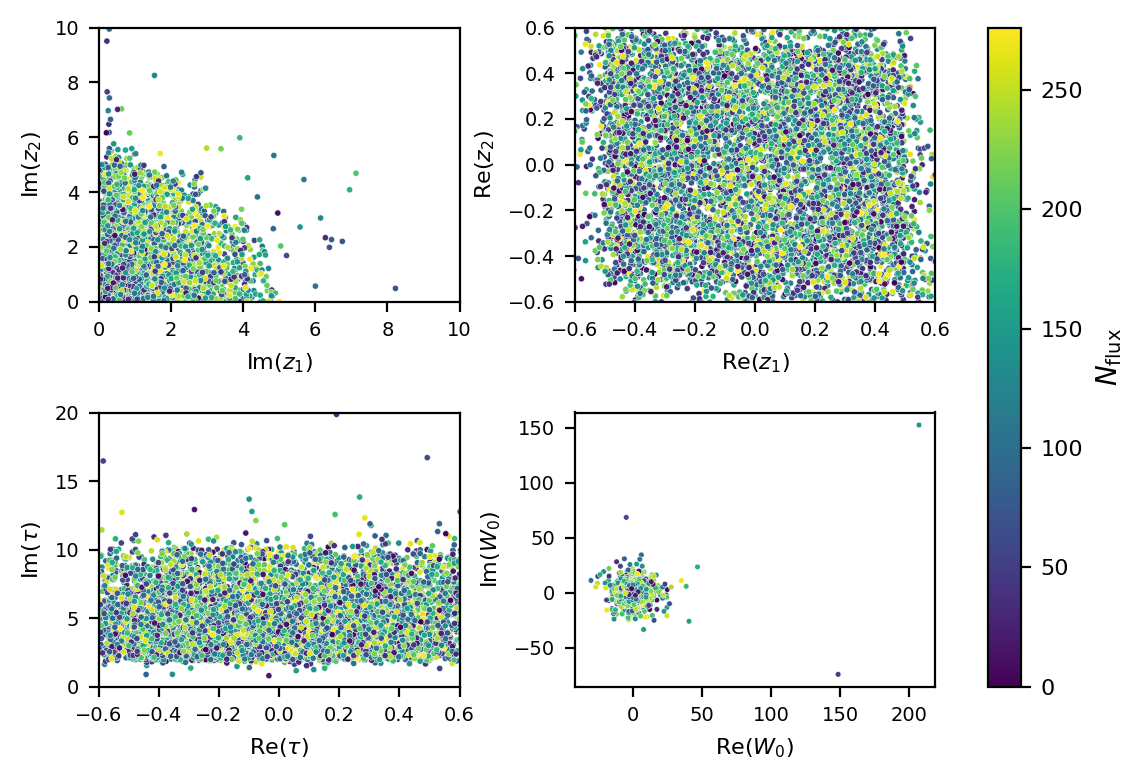

In [23]:
fig, ax = plt.subplots(2, 2,dpi=200,figsize=(6,4))

fs = 8

sn.scatterplot(x=moduli[:,0].imag,y=moduli[:,1].imag,s=5,ax=ax[0,0],hue = Nflux,palette=cmap)
ax[0,0].set_xlim(0,10)
ax[0,0].set_ylim(0,10)
ax[0,0].legend_.remove()
ax[0,0].set_xlabel(r"Im$(z_1)$",fontsize = fs)
ax[0,0].set_ylabel(r"Im$(z_2)$",fontsize = fs)

sn.scatterplot(x=moduli[:,0].real,y=moduli[:,1].real,s=5,ax=ax[0,1],hue = Nflux,palette=cmap)
ax[0,1].set_xlim(-0.6,0.6)
ax[0,1].set_ylim(-0.6,0.6)
ax[0,1].legend_.remove()
ax[0,1].set_xlabel(r"Re$(z_1)$",fontsize = fs)
ax[0,1].set_ylabel(r"Re$(z_2)$",fontsize = fs)


sn.scatterplot(x=taus.real,y=taus.imag,s=5,ax=ax[1,0],hue = Nflux,palette=cmap)
ax[1,0].set_xlim(-0.6,0.6)
ax[1,0].set_ylim(0,20)
ax[1,0].legend_.remove()
ax[1,0].set_xlabel(r"Re$(\tau)$",fontsize = fs)
ax[1,0].set_ylabel(r"Im$(\tau)$",fontsize = fs)

sn.scatterplot(x=W0.real,y=W0.imag,s=4,ax=ax[1,1],hue = Nflux,palette=cmap)
ax[1,1].legend_.remove()
ax[1,1].set_xlabel(r"Re$(W_0)$",fontsize = fs)
ax[1,1].set_ylabel(r"Im$(W_0)$",fontsize = fs)

for i in range(2):
    for j in range(2):
        ax[i,j].tick_params(labelsize=fs-1) 

plt.tight_layout()

norm = plt.Normalize(min(Nflux),max(Nflux))
sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
sm.set_array([])
clb = fig.colorbar(sm, label=r"$N_{\mathrm{flux}}$", ax=ax.ravel().tolist())

clb.ax.tick_params(labelsize=fs)

plt.show()